In [1]:
# ============================================================
#  环境配置
#  - Colab 用户：取消注释下方 Colab 区块，注释掉 Local 区块
#  - 本地 Jupyter 用户：直接运行 Local 区块
# ============================================================

# ── Colab 环境（取消注释后运行） ──
# !pip install torch>=2.1.0 -q
# !pip install torch_geometric>=2.4.0 -q
# !pip install matplotlib>=3.9.4 numpy>=1.26.4 -q

# ── 本地 Jupyter 环境 ──
import subprocess, sys
def _install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

_install("torch>=2.1.0")
_install("torch_geometric>=2.4.0")   # PyTorch Geometric
_install("matplotlib>=3.9.4")
_install("numpy>=1.26.4")

In [1]:
# 一键安装 Colab 环境依赖
!pip install torch>=2.1.0 torch_geometric>=2.4.0 matplotlib>=3.9.4 numpy>=1.26.4 -q

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# GNN 从零到一：GCN / GAT / GIN 源代码实现 vs 简洁实现

基于三篇经典论文，用 **节点分类** 任务演示图神经网络的核心架构：
- **GCN** — *Semi-Supervised Classification with Graph Convolutional Networks* (Kipf & Welling, 2017)
- **GAT** — *Graph Attention Networks* (Veličković et al., 2018)
- **GIN** — *How Powerful are Graph Neural Networks?* (Xu et al., 2019)

本 Notebook 包含两种实现，使用 **相同的超参数和数据**：

| | 实现 A — 源代码实现 | 实现 B — 简洁实现 |
|---|---|---|
| 核心思路 | 纯 PyTorch 手写消息传递，含公式推导 | 调用 `torch_geometric.nn` 高层 API |
| 代码量 | ~150 行（3 个模型） | ~60 行（3 个模型） |
| 适合场景 | 深入理解消息传递机制、面试准备 | 快速原型、工程落地 |
| 覆盖模型 | GCN + GAT + GIN | GCNConv + GATConv + GINConv |

## 1. 数据准备

使用 **Cora** 引文网络数据集——GNN 最经典的 benchmark。

| 属性 | 值 |
|------|-----|
| 节点数 | 2708（论文） |
| 边数 | 10556（引用关系，无向） |
| 节点特征维度 | 1433（词袋向量） |
| 类别数 | 7（论文主题） |
| 训练/验证/测试 | 140 / 500 / 1000（标准划分） |

Cora 是一个**引文图**：每个节点是一篇论文，边表示引用关系，节点特征是词袋向量，任务是根据引用网络结构和文本特征预测论文的研究领域。

In [3]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='./data/Cora', name='Cora')
data = dataset[0].to(device)

print(f'节点数: {data.num_nodes}')
print(f'边数:   {data.num_edges}')
print(f'特征维度: {data.num_node_features}')
print(f'类别数:   {dataset.num_classes}')
print(f'训练节点: {data.train_mask.sum().item()}')
print(f'验证节点: {data.val_mask.sum().item()}')
print(f'测试节点: {data.test_mask.sum().item()}')
print(f'\n节点特征 x: {data.x.shape}')         # (2708, 1433)
print(f'边索引 edge_index: {data.edge_index.shape}')  # (2, 10556)
print(f'标签 y: {data.y.shape}')                # (2708,)

Processing...
Done!


节点数: 2708
边数:   10556
特征维度: 1433
类别数:   7
训练节点: 140
验证节点: 500
测试节点: 1000

节点特征 x: torch.Size([2708, 1433])
边索引 edge_index: torch.Size([2, 10556])
标签 y: torch.Size([2708])


## 2. 共享组件

超参数、训练循环、评估函数——所有模型共用。

In [4]:
# ── 超参数（所有模型共用，集中管理） ──
HIDDEN_DIM  = 64      # 隐藏层维度（论文 GCN=16, GAT=8*8）
NUM_HEADS   = 4       # GAT 注意力头数
DROPOUT     = 0.5     # 论文值
LR          = 0.01    # 论文学习率
WEIGHT_DECAY = 5e-4   # 论文权重衰减
NUM_EPOCHS  = 200     # Cora 标准训练轮数（CPU 每轮 <0.1s）
IN_DIM      = dataset.num_node_features  # 1433
OUT_DIM     = dataset.num_classes        # 7

In [5]:
def train_node_clf(model, data, num_epochs, lr, weight_decay):
    """节点分类通用训练函数。Cora 是单图，整图训练。"""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_losses, val_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        out = model(data.x, data.edge_index)           # (num_nodes, num_classes)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        acc = eval_node_clf(model, data, data.val_mask)
        val_accs.append(acc)

        if (epoch + 1) % 50 == 0:
            print(f'Epoch {epoch+1:3d}/{num_epochs}, '
                  f'Loss: {loss.item():.4f}, Val Acc: {acc:.2%}')

    test_acc = eval_node_clf(model, data, data.test_mask)
    print(f'Test Acc: {test_acc:.2%}')
    return train_losses, val_accs, test_acc


@torch.no_grad()
def eval_node_clf(model, data, mask):
    """计算节点分类准确率。"""
    model.eval()
    pred = model(data.x, data.edge_index).argmax(dim=1)
    return (pred[mask] == data.y[mask]).float().mean().item()


def plot_results(losses, accs, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
    ax1.plot(losses); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax2.plot(accs); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title('Validation Accuracy')
    if title: fig.suptitle(title, fontsize=12)
    plt.tight_layout(); plt.show()

---
# 3. 实现 A — 源代码实现（From Scratch）

纯 PyTorch 手写三种 GNN 层，不依赖 `torch_geometric.nn`。

> **GNN 统一框架（消息传递）**：所有 GNN 都可以概括为：
> 1. **Aggregate**：从邻居收集信息
> 2. **Update**：结合自身特征更新表示
> 3. **Readout**（图级任务）：汇总所有节点特征

三种模型的核心区别在于 **Aggregate 的方式**：

| 模型 | 聚合方式 | 权重来源 | 理论表达力 |
|------|---------|---------|-----------|
| GCN | 对称归一化加权求和 | 固定（由节点度决定） | < 1-WL |
| GAT | 注意力加权求和 | 可学习（注意力机制） | < 1-WL |
| GIN | 直接求和 + MLP | 无权重（纯求和） | = 1-WL |

### 3.1 GCN（Graph Convolutional Network）

**GCN 传播公式**（Kipf & Welling, 2017）：

$$H^{(l+1)} = \sigma\left(\hat{D}^{-\frac{1}{2}} \hat{A} \hat{D}^{-\frac{1}{2}} H^{(l)} W^{(l)}\right)$$

其中：
- $\hat{A} = A + I_N$：添加自环的邻接矩阵
- $\hat{D}_{ii} = \sum_j \hat{A}_{ij}$：度矩阵
- $\hat{D}^{-1/2} \hat{A} \hat{D}^{-1/2}$：**对称归一化**，消除节点度数差异的影响
- $W^{(l)}$：可学习权重矩阵
- $\sigma$：激活函数（ReLU）

**逐节点公式**：

$$h_i^{(l+1)} = \sigma\left(\sum_{j \in \mathcal{N}(i) \cup \{i\}} \frac{1}{\sqrt{\hat{d}_i \cdot \hat{d}_j}} h_j^{(l)} W^{(l)}\right)$$

每个邻居的贡献按 $\frac{1}{\sqrt{d_i \cdot d_j}}$ 归一化——度数越高的节点，每条边的权重越小。

In [6]:
class GCNLayerScratch(nn.Module):
    """GCN 单层：对称归一化 + 线性变换。"""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_dim))

    def forward(self, x, edge_index):
        # x: (num_nodes, in_dim), edge_index: (2, num_edges)
        num_nodes = x.size(0)

        # 1. 添加自环：A_hat = A + I
        self_loops = torch.arange(num_nodes, device=x.device).unsqueeze(0).repeat(2, 1)
        edge_index_hat = torch.cat([edge_index, self_loops], dim=1)  # (2, num_edges + num_nodes)

        # 2. 计算度 D_hat
        # PyG 约定：edge_index[0]=source, edge_index[1]=target
        row, col = edge_index_hat[1], edge_index_hat[0]   # row=target, col=source
        deg = torch.zeros(num_nodes, device=x.device)
        deg.scatter_add_(0, row, torch.ones(row.size(0), device=x.device))

        # 3. D^{-1/2}
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0.0

        # 4. 归一化系数：1 / sqrt(d_i * d_j)
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]   # (num_edges + num_nodes,)

        # 5. 线性变换 X * W
        x = self.linear(x)                              # (num_nodes, out_dim)

        # 6. 消息传递：聚合归一化的邻居特征
        out = torch.zeros_like(x)
        # scatter_add: out[target] += norm * x[source]
        out.scatter_add_(0, row.unsqueeze(1).expand_as(x[col]),
                         norm.unsqueeze(1) * x[col])

        return out + self.bias                           # (num_nodes, out_dim)


class GCNScratch(nn.Module):
    """2 层 GCN 完整模型。"""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=DROPOUT):
        super().__init__()
        self.conv1 = GCNLayerScratch(in_dim, hidden_dim)
        self.conv2 = GCNLayerScratch(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)                   # (N, hidden_dim)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)                   # (N, out_dim)
        return x

### 3.2 GAT（Graph Attention Network）

**GAT 注意力公式**（Veličković et al., 2018）：

**第 1 步：计算注意力分数**

$$e_{ij} = \text{LeakyReLU}\left(\mathbf{a}^T [\mathbf{W} h_i \| \mathbf{W} h_j]\right)$$

**第 2 步：Softmax 归一化**

$$\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k \in \mathcal{N}(i)} \exp(e_{ik})}$$

**第 3 步：加权聚合**

$$h_i^{(l+1)} = \sigma\left(\sum_{j \in \mathcal{N}(i) \cup \{i\}} \alpha_{ij} \mathbf{W} h_j\right)$$

**多头注意力**：使用 $K$ 个独立的注意力头，拼接（中间层）或取平均（输出层）：

$$h_i^{(l+1)} = \|_{k=1}^{K} \sigma\left(\sum_{j} \alpha_{ij}^k \mathbf{W}^k h_j\right)$$

与 GCN 的**关键区别**：GCN 权重由节点度固定决定，GAT 权重由**可学习的注意力机制**动态计算。

In [7]:
class GATLayerScratch(nn.Module):
    """GAT 单头注意力层。"""
    def __init__(self, in_dim, out_dim, negative_slope=0.2):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        # 注意力向量 a = [a_left || a_right]，分别对应目标节点和源节点
        self.a_left = nn.Parameter(torch.zeros(out_dim, 1))
        self.a_right = nn.Parameter(torch.zeros(out_dim, 1))
        nn.init.xavier_uniform_(self.a_left)
        nn.init.xavier_uniform_(self.a_right)
        self.leaky_relu = nn.LeakyReLU(negative_slope)

    def forward(self, x, edge_index):
        # x: (N, in_dim), edge_index: (2, E)
        num_nodes = x.size(0)

        # 添加自环
        self_loops = torch.arange(num_nodes, device=x.device).unsqueeze(0).repeat(2, 1)
        edge_index = torch.cat([edge_index, self_loops], dim=1)
        # PyG 约定：edge_index[0]=source, edge_index[1]=target
        row, col = edge_index[1], edge_index[0]            # row=target, col=source

        # 线性变换
        Wh = self.W(x)                                     # (N, out_dim)

        # 计算注意力分数 e_ij = LeakyReLU(a_left^T Wh_target + a_right^T Wh_source)
        e_left = (Wh @ self.a_left).squeeze(-1)            # (N,)
        e_right = (Wh @ self.a_right).squeeze(-1)          # (N,)
        e = self.leaky_relu(e_left[row] + e_right[col])    # (E,)

        # Softmax 归一化（对每个目标节点的所有入边）
        e_max = torch.zeros(num_nodes, device=x.device)
        e_max.scatter_reduce_(0, row, e, reduce='amax', include_self=False)
        e_exp = torch.exp(e - e_max[row])                  # 数值稳定的 exp
        e_sum = torch.zeros(num_nodes, device=x.device)
        e_sum.scatter_add_(0, row, e_exp)
        alpha = e_exp / (e_sum[row] + 1e-16)               # (E,) 归一化注意力权重

        # 加权聚合：out[target] += alpha * Wh[source]
        out = torch.zeros(num_nodes, Wh.size(1), device=x.device)
        out.scatter_add_(0, row.unsqueeze(1).expand_as(Wh[col]),
                         alpha.unsqueeze(1) * Wh[col])     # (N, out_dim)
        return out


class GATScratch(nn.Module):
    """多头 GAT 完整模型：中间层拼接，输出层取平均。"""
    def __init__(self, in_dim, hidden_dim, out_dim, heads=NUM_HEADS, dropout=DROPOUT):
        super().__init__()
        self.heads1 = nn.ModuleList([
            GATLayerScratch(in_dim, hidden_dim) for _ in range(heads)])
        # 输出层：单头（等效于多头取平均）
        self.out_layer = GATLayerScratch(hidden_dim * heads, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        # 多头注意力：拼接
        x = torch.cat([head(x, edge_index) for head in self.heads1], dim=-1)
        x = F.elu(x)                                       # (N, hidden_dim * heads)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.out_layer(x, edge_index)                   # (N, out_dim)
        return x

### 3.3 GIN（Graph Isomorphism Network）

**GIN 更新公式**（Xu et al., 2019）：

$$h_v^{(k)} = \text{MLP}^{(k)}\left((1 + \varepsilon^{(k)}) \cdot h_v^{(k-1)} + \sum_{u \in \mathcal{N}(v)} h_u^{(k-1)}\right)$$

- **Sum 聚合**（非 mean/max）：保持**单射性**（injectivity），不同的邻居多重集产生不同的聚合结果
- **$\varepsilon^{(k)}$**：可学习标量，控制自身特征的权重
- **MLP**：提升非线性表达能力

**为什么 Sum > Mean > Max？**
- `{1,1,1}` 和 `{1}`：Mean 无法区分（均为 1），Sum 可以（3 vs 1）
- `{1,2,3}` 和 `{1,1,3}`：Max 无法区分（均为 3），Sum 可以（6 vs 5）

GIN 的理论表达力等价于 **1-WL 图同构测试**，是所有消息传递 GNN 的理论上界。

In [8]:
class GINLayerScratch(nn.Module):
    """GIN 单层：Sum 聚合 + MLP 更新。"""
    def __init__(self, in_dim, out_dim, train_eps=True):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, out_dim),
        )
        # 可学习的 epsilon
        if train_eps:
            self.eps = nn.Parameter(torch.zeros(1))
        else:
            self.register_buffer('eps', torch.zeros(1))

    def forward(self, x, edge_index):
        # x: (N, in_dim), edge_index: (2, E)
        num_nodes = x.size(0)
        # PyG 约定：edge_index[0]=source, edge_index[1]=target
        row, col = edge_index[1], edge_index[0]            # row=target, col=source

        # Sum 聚合邻居特征：agg[target] += x[source]
        agg = torch.zeros(num_nodes, x.size(1), device=x.device)
        agg.scatter_add_(0, row.unsqueeze(1).expand_as(x[col]), x[col])  # (N, in_dim)

        # (1 + eps) * h_self + sum(h_neighbors)
        out = (1 + self.eps) * x + agg                     # (N, in_dim)
        return self.mlp(out)                               # (N, out_dim)


class GINScratch(nn.Module):
    """2 层 GIN 完整模型。"""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=DROPOUT):
        super().__init__()
        self.conv1 = GINLayerScratch(in_dim, hidden_dim)
        self.conv2 = GINLayerScratch(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)                      # (N, hidden_dim)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)                      # (N, hidden_dim)
        x = F.relu(x)
        x = self.classifier(x)                             # (N, out_dim)
        return x

### 3.4 训练实现 A（三个模型）


训练 GCN — 源代码实现
参数量: 92,231
Epoch  50/200, Loss: 0.0153, Val Acc: 78.80%
Epoch 100/200, Loss: 0.0132, Val Acc: 77.20%
Epoch 150/200, Loss: 0.0126, Val Acc: 76.20%
Epoch 200/200, Loss: 0.0097, Val Acc: 77.00%
Test Acc: 80.60%


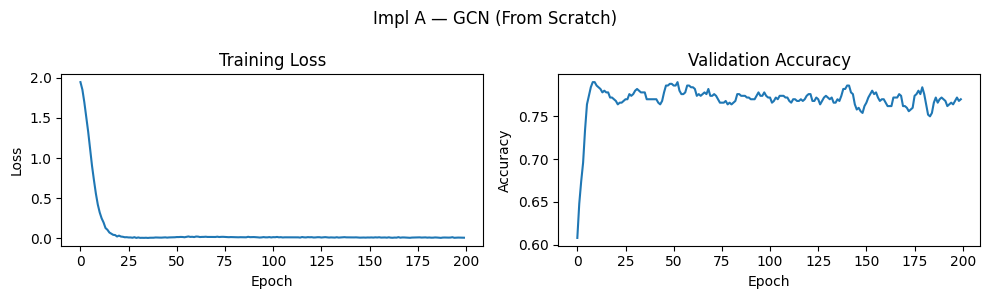


训练 GAT — 源代码实现
参数量: 369,166
Epoch  50/200, Loss: 0.0230, Val Acc: 75.80%
Epoch 100/200, Loss: 0.0070, Val Acc: 75.60%
Epoch 150/200, Loss: 0.0055, Val Acc: 75.80%
Epoch 200/200, Loss: 0.0165, Val Acc: 77.20%
Test Acc: 77.00%


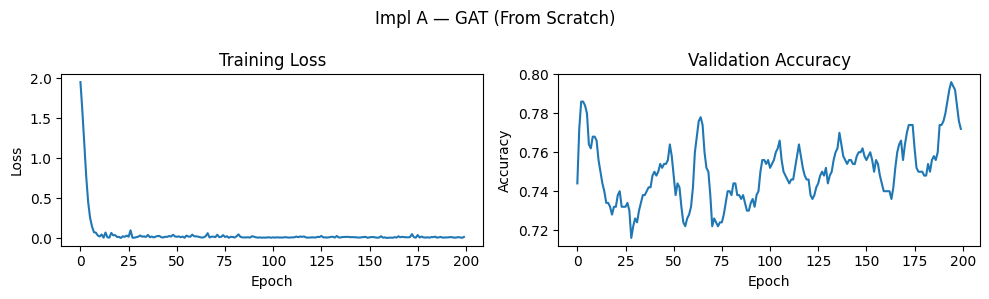


训练 GIN — 源代码实现
参数量: 104,713
Epoch  50/200, Loss: 0.0029, Val Acc: 70.80%
Epoch 100/200, Loss: 0.0009, Val Acc: 71.60%
Epoch 150/200, Loss: 0.3039, Val Acc: 70.00%
Epoch 200/200, Loss: 0.0013, Val Acc: 67.60%
Test Acc: 69.00%


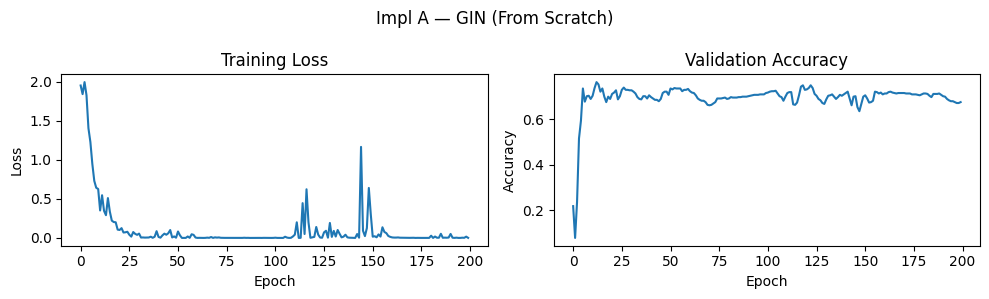

In [9]:
results_a = {}
for name, ModelClass in [('GCN', GCNScratch), ('GAT', GATScratch), ('GIN', GINScratch)]:
    print(f'\n{"="*50}')
    print(f'训练 {name} — 源代码实现')
    print(f'{"="*50}')
    torch.manual_seed(42)
    model = ModelClass(IN_DIM, HIDDEN_DIM, OUT_DIM).to(device)
    params = sum(p.numel() for p in model.parameters())
    print(f'参数量: {params:,}')
    losses, accs, test_acc = train_node_clf(model, data, NUM_EPOCHS, LR, WEIGHT_DECAY)
    results_a[name] = {'losses': losses, 'accs': accs, 'test_acc': test_acc, 'model': model}
    plot_results(losses, accs, f'Impl A — {name} (From Scratch)')

---
# 4. 实现 B — 简洁实现（PyTorch Geometric）

使用 `torch_geometric.nn` 的内置卷积层，代码量大幅减少。

| 源代码实现 | 简洁实现 (`torch_geometric.nn`) |
|---|---|
| `GCNLayerScratch`（scatter_add 手写消息传递） | `GCNConv(in_dim, out_dim)` |
| `GATLayerScratch`（手写注意力 + softmax） | `GATConv(in_dim, out_dim, heads=K)` |
| `GINLayerScratch`（手写 sum + MLP） | `GINConv(nn=MLP, train_eps=True)` |

In [10]:
from torch_geometric.nn import GCNConv, GATConv, GINConv


class GCNConcise(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=DROPOUT):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)


class GATConcise(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=NUM_HEADS, dropout=DROPOUT):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout)
        # 输出层: concat=False 取平均
        self.conv2 = GATConv(hidden_dim * heads, out_dim, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)


class GINConcise(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=DROPOUT):
        super().__init__()
        mlp1 = nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.ReLU(),
                             nn.Linear(hidden_dim, hidden_dim))
        mlp2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                             nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINConv(nn=mlp1, train_eps=True)
        self.conv2 = GINConv(nn=mlp2, train_eps=True)
        self.classifier = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        return self.classifier(x)

### 4.1 训练实现 B（三个模型）


训练 GCN — 简洁实现 (PyG)
参数量: 92,231
Epoch  50/200, Loss: 0.0096, Val Acc: 78.60%
Epoch 100/200, Loss: 0.0134, Val Acc: 76.40%
Epoch 150/200, Loss: 0.0105, Val Acc: 77.60%
Epoch 200/200, Loss: 0.0090, Val Acc: 75.60%
Test Acc: 81.30%


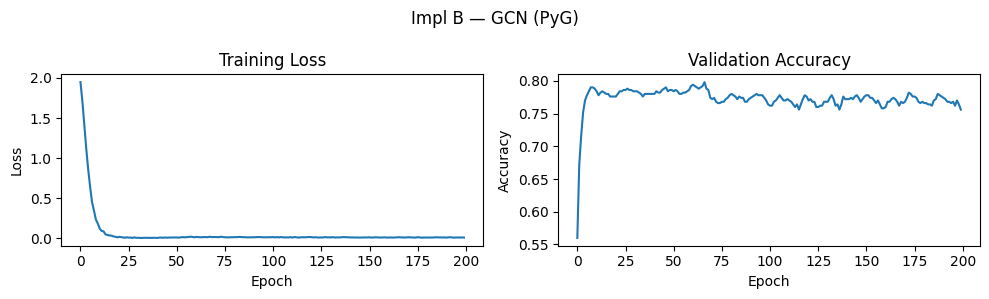


训练 GAT — 简洁实现 (PyG)
参数量: 369,429
Epoch  50/200, Loss: 0.2147, Val Acc: 78.80%
Epoch 100/200, Loss: 0.2614, Val Acc: 75.40%
Epoch 150/200, Loss: 0.1564, Val Acc: 76.80%
Epoch 200/200, Loss: 0.1577, Val Acc: 77.00%
Test Acc: 78.10%


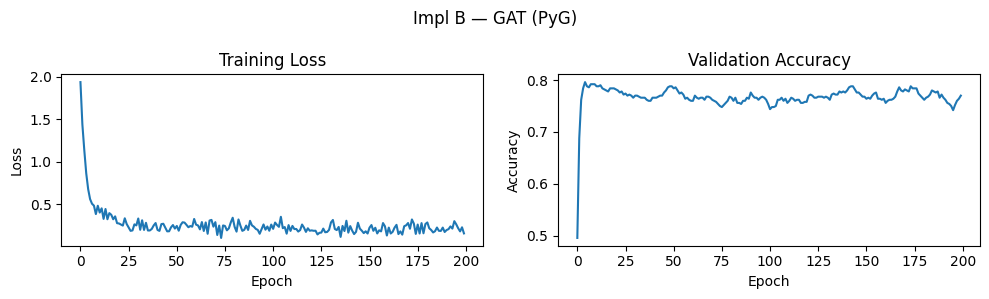


训练 GIN — 简洁实现 (PyG)
参数量: 104,713
Epoch  50/200, Loss: 0.0024, Val Acc: 73.80%
Epoch 100/200, Loss: 0.3407, Val Acc: 72.60%
Epoch 150/200, Loss: 0.0120, Val Acc: 70.40%
Epoch 200/200, Loss: 0.0003, Val Acc: 68.20%
Test Acc: 70.50%


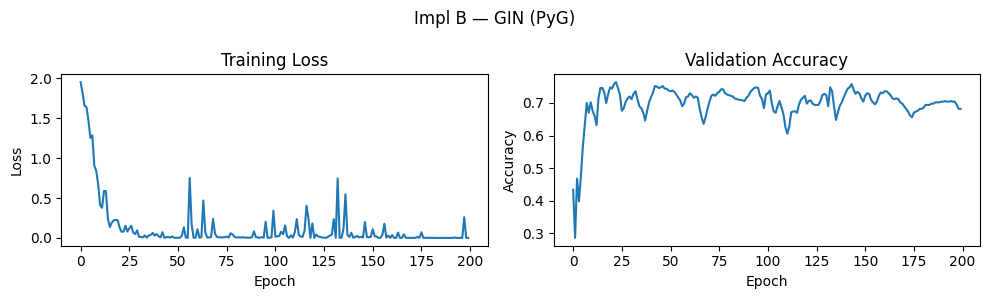

In [11]:
results_b = {}
for name, ModelClass in [('GCN', GCNConcise), ('GAT', GATConcise), ('GIN', GINConcise)]:
    print(f'\n{"="*50}')
    print(f'训练 {name} — 简洁实现 (PyG)')
    print(f'{"="*50}')
    torch.manual_seed(42)
    model = ModelClass(IN_DIM, HIDDEN_DIM, OUT_DIM).to(device)
    params = sum(p.numel() for p in model.parameters())
    print(f'参数量: {params:,}')
    losses, accs, test_acc = train_node_clf(model, data, NUM_EPOCHS, LR, WEIGHT_DECAY)
    results_b[name] = {'losses': losses, 'accs': accs, 'test_acc': test_acc}
    plot_results(losses, accs, f'Impl B — {name} (PyG)')

---
# 5. 结果对比

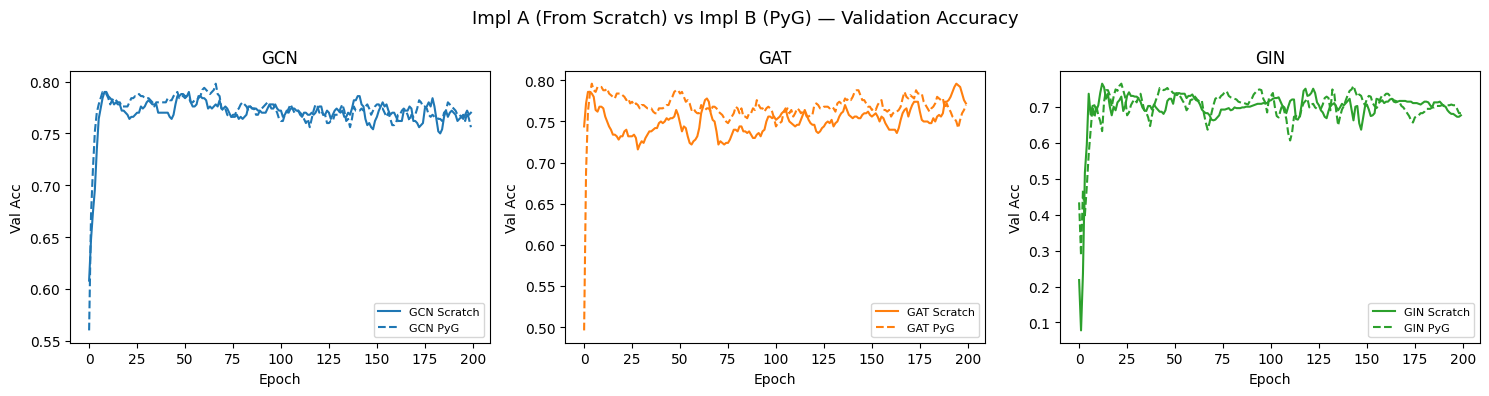


模型           源代码 Test Acc    PyG Test Acc
------------------------------------------
GCN               80.60%         81.30%
GAT               77.00%         78.10%
GIN               69.00%         70.50%


In [12]:
# 六条曲线对比
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_a = {'GCN': 'tab:blue', 'GAT': 'tab:orange', 'GIN': 'tab:green'}
for idx, name in enumerate(['GCN', 'GAT', 'GIN']):
    ax = axes[idx]
    ax.plot(results_a[name]['accs'], '-', color=colors_a[name], label=f'{name} Scratch')
    ax.plot(results_b[name]['accs'], '--', color=colors_a[name], label=f'{name} PyG')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val Acc')
    ax.set_title(name); ax.legend(fontsize=8)
plt.suptitle('Impl A (From Scratch) vs Impl B (PyG) — Validation Accuracy', fontsize=13)
plt.tight_layout(); plt.show()

# 汇总表
print(f'\n{"模型":<6} {"源代码 Test Acc":>18} {"PyG Test Acc":>15}')
print('-' * 42)
for name in ['GCN', 'GAT', 'GIN']:
    print(f'{name:<6} {results_a[name]["test_acc"]:>17.2%} {results_b[name]["test_acc"]:>14.2%}')

---
# 附录 A：GAT 注意力权重可视化

Epoch  50/200, Loss: 0.2147, Val Acc: 78.80%
Epoch 100/200, Loss: 0.2614, Val Acc: 75.40%
Epoch 150/200, Loss: 0.1564, Val Acc: 76.80%
Epoch 200/200, Loss: 0.1577, Val Acc: 77.00%
Test Acc: 78.10%


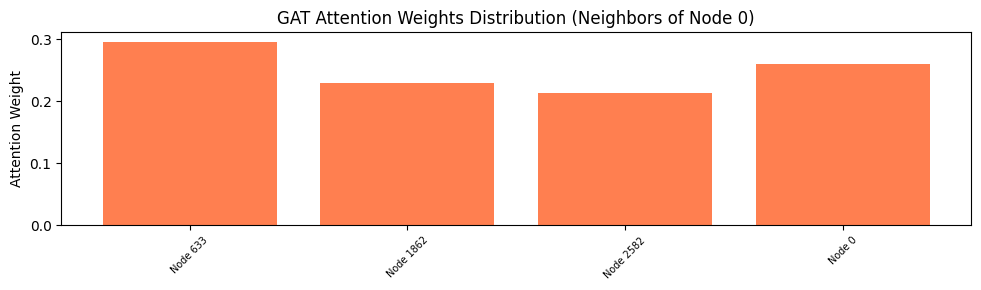

Node 0 has 4 neighbors (including self-loop)


In [14]:
# 用 PyG 的 GATConv 提取注意力权重（return_attention_weights=True）
gat_model = results_a['GAT']['model']
gat_model.eval()

# 重新训练一个 PyG GAT 来提取注意力权重
torch.manual_seed(42)
gat_vis = GATConcise(IN_DIM, HIDDEN_DIM, OUT_DIM).to(device)
_ = train_node_clf(gat_vis, data, NUM_EPOCHS, LR, WEIGHT_DECAY)
gat_vis.eval()

# 提取第一层的注意力权重
with torch.no_grad():
    x = F.dropout(data.x, p=DROPOUT, training=False)
    out, (edge_idx, alpha) = gat_vis.conv1(x, data.edge_index,
                                            return_attention_weights=True)

# 可视化某个节点的注意力分布
# PyG 约定：edge_idx[0]=source, edge_idx[1]=target
target_node = 0
mask = edge_idx[1] == target_node                          # 指向 target 的边
neighbor_ids = edge_idx[0][mask].cpu().numpy()              # 源节点（邻居）
attention_weights = alpha[mask].mean(dim=1).cpu().numpy()   # 多头平均

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(neighbor_ids)), attention_weights, color='coral')
ax.set_xticks(range(len(neighbor_ids)))
ax.set_xticklabels([f'Node {n}' for n in neighbor_ids], rotation=45, fontsize=7)
ax.set_ylabel('Attention Weight')
ax.set_title(f'GAT Attention Weights Distribution (Neighbors of Node {target_node})')
plt.tight_layout(); plt.show()
print(f'Node {target_node} has {len(neighbor_ids)} neighbors (including self-loop)')

---
# 附录 B：面试拓展

## 高频面试题

**Q1: 消息传递（Message Passing）的核心步骤是什么？**

三步：
1. **Message**：邻居节点将自身特征变换为"消息"
2. **Aggregate**：将所有邻居消息聚合到中心节点（sum / mean / max / attention）
3. **Update**：将聚合结果与自身特征结合，经非线性变换更新表示

通用公式：$h_v^{(k)} = \text{UPDATE}(h_v^{(k-1)}, \text{AGG}(\{h_u^{(k-1)} : u \in \mathcal{N}(v)\}))$

K 层 GNN 可捕获 K-hop 邻域信息。

---

**Q2: GCN、GAT、GIN 的核心区别是什么？**

| 维度 | GCN | GAT | GIN |
|------|-----|-----|-----|
| 聚合权重 | 固定（节点度归一化） | 可学习（注意力） | 无权重（纯求和） |
| 核心公式 | $\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}XW$ | $\sum \alpha_{ij} Wh_j$ | $\text{MLP}((1+\varepsilon)h_i + \sum h_j)$ |
| 理论表达力 | < 1-WL | < 1-WL | **= 1-WL** |
| 最佳任务 | 节点分类（同质图） | 异质图/邻居重要性不同 | 图分类（需最大表达力） |

---

**Q3: 什么是过平滑（Over-Smoothing）？如何缓解？**

随着层数增加，所有节点表示趋向收敛到同一值。K 层 GCN 等价于 K 步随机游走，K→∞ 时节点影响力趋向平稳分布。

**缓解方法**：
1. **残差连接**：DeepGCNs 借鉴 ResNet
2. **DropEdge**：训练时随机丢弃边（ICLR 2020）
3. **JK-Net**：融合各层表示而非仅用最后一层
4. **门控更新**：借鉴 GRU，动态控制信息保留比例

---

**Q4: WL Test 与 GNN 表达能力的关系？**

WL Test（Weisfeiler-Lehman 图同构测试）通过迭代聚合邻居标签并哈希来判定图同构。
- **GNN 的表达能力上界是 1-WL test**（Xu et al., 2019）
- Mean/Max 聚合严格弱于 1-WL（无法区分某些多重集）
- **GIN 的 Sum + MLP = 单射映射 = 1-WL**

---

**Q5: 为什么 GIN 的 Sum 聚合比 Mean/Max 强？**

核心是**单射性**：
- Sum：`{1,1,1}` → 3，`{1}` → 1，可区分
- Mean：`{1,1,1}` → 1，`{1}` → 1，**无法区分**
- Max：`{1,2,3}` → 3，`{1,1,3}` → 3，**无法区分**

但 Mean 在节点分类上常常表现也不错——当任务只关心特征分布而非精确结构时，Mean 足够有效。

---

**Q6: Inductive vs Transductive Learning？**

| 维度 | Transductive（直推式） | Inductive（归纳式） |
|------|----------------------|-------------------|
| 代表模型 | GCN | GraphSAGE, GAT, GIN |
| 学习目标 | 每个节点的唯一表征 | 聚合函数（可泛化） |
| 新节点 | 需重新训练 | 可直接推断 |
| 工业适用 | 静态图 | **动态图**（推荐） |

---

**Q7: 图池化（Graph Pooling）有哪些策略？**

将节点级表征聚合为图级表征，用于图分类：
1. **全局池化**：Sum（GIN 推荐，保持单射性）/ Mean / Max
2. **层次化池化**：DiffPool（软分配）、SAGPool（top-k 选择）
3. **GIN Readout**：$h_G = \text{CONCAT}_k(\sum_{v} h_v^{(k)})$，融合每层信息

---

**Q8: Over-Squashing 与 Over-Smoothing 的区别？**

| | Over-Smoothing | Over-Squashing |
|---|---|---|
| 现象 | 节点表征趋同 | 远距离信息被"压缩"丢失 |
| 原因 | 反复邻域平均 = 低通滤波 | 指数增长的邻域塞入固定维向量 |
| 出现条件 | 层数多（即使图结构好） | 图存在瓶颈结构 |
| 解决 | 残差、DropEdge、JK-Net | 图重布线（Graph Rewiring） |

---

**Q9: GNN 中 Batch Normalization 效果如何？**

与 CNN 不同，GNN 中 BN 效果不稳定。原因：图数据的节点数、度分布差异很大，BN 的统计量不稳定。替代方案：
- **GraphNorm**：引入可学习的均值移除比例
- **PairNorm**：保持节点表示的散度，缓解过平滑
- **LayerNorm**：对每个节点独立归一化

---

**Q10: GraphSAGE 的采样策略为什么重要？**

GraphSAGE 对每个节点**固定采样** K 个邻居（而非全部聚合），解决了：
- **内存问题**：大图中某些节点度数极高（如社交网络的大V），全聚合会 OOM
- **计算效率**：固定采样使 mini-batch 训练成为可能
- **归纳能力**：学习的是聚合函数而非节点表征，可泛化到新图

三种聚合方式：Mean / Max-pooling / LSTM（按随机顺序输入邻居）

---

## 延伸阅读与对比

| 对比维度 | GCN (2017) | GAT (2018) | GIN (2019) | GraphSAGE (2017) |
|---------|------------|------------|------------|-----------------|
| 聚合方式 | 对称归一化 | 注意力加权 | Sum + MLP | Mean/Max/LSTM |
| 权重类型 | 固定（度数） | 可学习 | 无（纯求和） | 可学习 |
| 理论表达力 | < 1-WL | < 1-WL | = 1-WL | < 1-WL |
| Inductive | 否 | 是 | 是 | 是 |
| 最佳场景 | 同质图节点分类 | 异质图 | 图分类 | 大规模图 |
| Cora 典型 Acc | ~81% | ~83% | ~78% | ~80% |

## 进阶探索方向

- **Graph Transformer**：用全局自注意力替代局部消息传递，克服 over-squashing
- **GNN+**（ICML 2025）：通过 6 种超参数技术（边特征、归一化、残差、FFN 等）使经典 GNN 性能匹敌 Graph Transformer
- **异质图神经网络（HGT）**：处理不同类型节点和边的图
- **时序图网络（TGN）**：处理动态演化的图结构